<a href="https://colab.research.google.com/github/Bendy545/Prague-Rent-Predictor/blob/dev/src/training/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd

df = pd.read_csv("sreality_cleaned.csv")
df

,price_czk,district,size_m2,room_count,has_separate_kitchen,floor_number,total_floors,building_type,condition,ownership,furnished,elevator,has_balcony,has_terrace,has_cellar,has_parking
0,50500,Praha 2,84,4,False,1,NaN,Smíšená,Po rekonstrukci,Osobní,Yes,Yes,False,False,False,False
1,45000,Praha 5,114,1,False,5,NaN,Skeletová,Velmi dobrý,Osobní,Partially,Yes,False,False,False,False
2,44000,Praha 2,111,3,False,3,NaN,Cihlová,Velmi dobrý,Osobní,Unknown,Unknown,True,False,False,False
3,26000,Praha 5,90,3,True,2,NaN,Cihlová,Po rekonstrukci,Osobní,Unknown,Unknown,False,True,False,False
4,41000,Praha 6,104,4,True,3,NaN,Cihlová,Velmi dobrý,Osobní,Partially,Unknown,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,55833,Praha 2,106,3,False,3,5.0,Cihlová,Velmi dobrý,Osobní,Yes,Yes,False,False,False,True
6310,28000,Praha 4,74,3,False,8,11.0,Cihlová,Novostavba,Osobní,Yes,Yes,False,False,False,True
6311,23000,Praha 9,50,2,False,2,NaN,Cihlová,Novostavba,Osobní,Yes,Unknown,True,False,False,True
6312,57000,Praha 2,33,1,False,2,5.0,Cihlová,Velmi dobrý,Osobní,Yes,Unknown,False,False,False,False


In [36]:
df.dtypes

,0
price_czk,int64
district,object
size_m2,int64
room_count,int64
has_separate_kitchen,bool
floor_number,int64
total_floors,float64
building_type,object
condition,object
ownership,object


How many NaN values dataset has

In [37]:
for col in df.columns:
  print(col, df[col].isna().sum())

price_czk 0
district 0
size_m2 0
room_count 0
has_separate_kitchen 0
floor_number 0
total_floors 2412
building_type 0
condition 0
ownership 0
furnished 0
elevator 0
has_balcony 0
has_terrace 0
has_cellar 0
has_parking 0


# Graphs

In [38]:
import matplotlib.pyplot as plt


Correlation showing how all features relate to price and each other

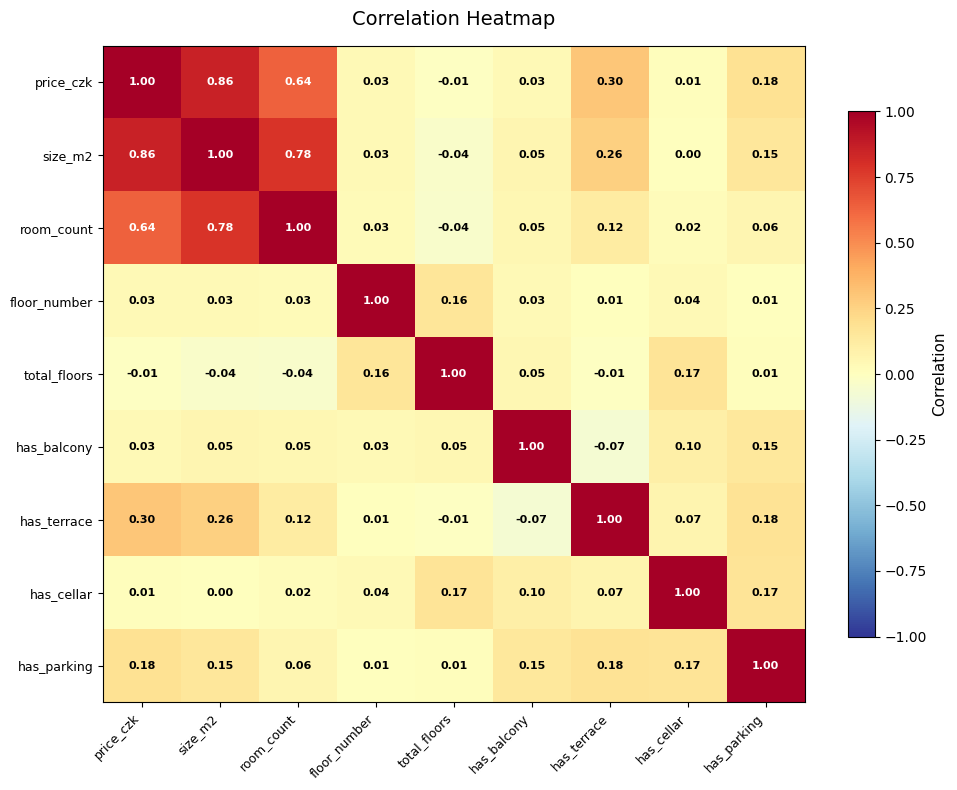

Correlations with price_czk
size_m2         0.855521
room_count      0.636659
has_terrace     0.299629
has_parking     0.179717
floor_number    0.034505
has_balcony     0.033791
has_cellar      0.009975
total_floors   -0.013864


In [39]:
num_cols = ['price_czk', 'size_m2', 'room_count', 'floor_number', 'total_floors', 'has_balcony', 'has_terrace', 'has_cellar', 'has_parking']

df_corr = df[num_cols].copy()
for col in ['has_balcony', 'has_terrace', 'has_cellar', 'has_parking']:
    df_corr[col] = df_corr[col].astype(int)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_matrix.values, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlation', fontsize=11)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        value = corr_matrix.values[i, j]
        text_color = 'white' if abs(value) > 0.5 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                fontsize=8, color=text_color, fontweight='bold')

ax.set_title('Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("Correlations with price_czk")
price_corr = corr_matrix['price_czk'].drop('price_czk').sort_values(ascending=False)
print(price_corr.to_string())


# Defining features

In [40]:
numerical_features = ['size_m2', 'room_count', 'floor_number']
categorical_features = ['district', 'building_type', 'condition', 'ownership', 'furnished', 'elevator']
boolean_features = ['has_separate_kitchen', 'has_balcony', 'has_terrace', 'has_cellar', 'has_parking']

target = 'price_czk'

all_features = numerical_features + categorical_features + boolean_features


# Converting boolean columns to int

In [41]:
for col in boolean_features:
  df[col] = df[col].astype(int)

df[boolean_features]

,has_separate_kitchen,has_balcony,has_terrace,has_cellar,has_parking
0,0,0,0,0,0
1,0,0,0,0,0
2,0,1,0,0,0
3,1,0,1,0,0
4,1,0,0,0,0
...,...,...,...,...,...
6309,0,0,0,0,1
6310,0,0,0,0,1
6311,0,1,0,0,1
6312,0,0,0,0,0


# Train/Test Split

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X = df[all_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building Pipeline

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ]
)

# Linear Regression

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])

lr_model.fit(X_train, y_train)

lr_y_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_y_pred))
lr_r2 = r2_score(y_test, lr_y_pred)

print(f"Linear Regression Results:")
print(f"MAE:  {lr_mae:,.0f} CZK")
print(f"RMSE: {lr_rmse:,.0f} CZK")
print(f"R²:   {lr_r2:.4f}")


Linear Regression Results:
MAE:  5,166 CZK
RMSE: 8,671 CZK
R²:   0.7252


# Random Forest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=300))])

rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"MAE:  {rf_mae}")
print(f"RMSE: {rf_rmse}")
print(f"R2: {rf_r2}")


MAE:  4158.783899560784
RMSE: 7659.355280502056
R2: 0.7855436577678588
